<a href="https://colab.research.google.com/github/VuTuanAnh0949/RAG-LangChain-Ablation-Study/blob/main/%5BSolution%5D_RAG_Ablation_Hydrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Environment Setup


### 1.1 Install required packages

In [ ]:
!pip install -q \
  "langchain>=0.2.0" \
  "langchain-core>=0.2.0" \
  "langchain-community>=0.1.0" \
  "langchain-text-splitters>=0.2.0" \
  "sentence-transformers>=2.2.0" \
  "langchain-huggingface>=0.0.1" \
  "chromadb>=0.5.0" \
  "langchain-chroma>=0.2.0" \
  "pypdf" \
  "ragas>=0.2.0" \
  "datasets>=2.14.0" \
  "pandas" \
  "matplotlib" \
  "seaborn" \
  "openai>=1.0.0" \
  "langchain-openai>=0.1.0" \
  "gdown" \
  "tiktoken" \
  "nest_asyncio" \
  "rank-bm25" \
  "underthesea"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 2.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 329.6/329.6 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.7/84.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.9/484.9 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.4/978.4 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.4 MB/s eta

### 1.2 Import libraries

In [ ]:
import os
import re
import json
import glob
import time
import gdown
import random
import asyncio
import unicodedata
import numpy as np
import pandas as pd
import seaborn as sns
import nest_asyncio
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

from tqdm import tqdm
from typing import List, Any, Optional
from openai import OpenAI
from google.colab import userdata
from langchain_chroma import Chroma
from rank_bm25 import BM25Okapi
from underthesea import word_tokenize

from datasets import Dataset

from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_core.retrievers import BaseRetriever
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.documents import Document as LangchainDocument
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pydantic import Field

from ragas import evaluate
from ragas.run_config import RunConfig
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall
)
from ragas.embeddings import LangchainEmbeddingsWrapper

nest_asyncio.apply()

/tmp/ipython-input-2346067710.py:40: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
/tmp/ipython-input-2346067710.py:40: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (
/tmp/ipython-input-2346067710.py:40: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import (
/tmp/ipython-input-2346067710.py:40: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed

### 1.3 Set global seed for reproducibility (SEED = 42)

In [ ]:
SEED = 42

def set_global_seed(seed_value: int = 42):
    random.seed(seed_value)
    np.random.seed(seed_value)
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    print(f"Global seed set to {seed_value}")

set_global_seed(SEED)

Global seed set to 42


### 1.4 Configure API Keys

In [ ]:
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

# os.environ["OPENAI_API_KEY"] = ""
OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]

print("OpenAI API Key configured successfully")

OpenAI API Key configured successfully


### 1.5 Batch Processing Configuration

In [ ]:
BATCH_SIZE = 32
EMBEDDING_BATCH_SIZE = 100

LLM_MODEL = "gpt-4o-mini"
EMBEDDING_MODEL = "text-embedding-3-small"

# Hybrid Search Configuration
CHUNK_SIZE = 1024
CHUNK_OVERLAP = 128
VECTOR_K = 5  # Number of docs from vector search
BM25_K = 5    # Number of docs from BM25 search
HYBRID_TOP_K = 5  # Final number of docs after merging

EVAL_SAMPLE_SIZE = None
EVAL_MAX_WORKERS = 64
EVAL_TIMEOUT = 180

print(f"Configuration:")
print(f"  - LLM Model: {LLM_MODEL}")
print(f"  - Embedding Model: {EMBEDDING_MODEL}")
print(f"  - Retrieval: HYBRID (BM25 + Vector)")
print(f"  - Vector Top-K: {VECTOR_K}")
print(f"  - BM25 Top-K: {BM25_K}")
print(f"  - Hybrid Final K: {HYBRID_TOP_K}")
print(f"  - Chunk Size: {CHUNK_SIZE}")
print(f"  - Chunk Overlap: {CHUNK_OVERLAP}")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - RAGAS Eval Workers: {EVAL_MAX_WORKERS}")
print(f"  - Eval Sample Size: {'ALL' if EVAL_SAMPLE_SIZE is None else EVAL_SAMPLE_SIZE}")

Configuration:
  - LLM Model: gpt-4o-mini
  - Embedding Model: text-embedding-3-small
  - Retrieval: HYBRID (BM25 + Vector)
  - Vector Top-K: 5
  - BM25 Top-K: 5
  - Hybrid Final K: 5
  - Chunk Size: 1024
  - Chunk Overlap: 128
  - Batch Size: 32
  - RAGAS Eval Workers: 64
  - Eval Sample Size: ALL


## 2. Data Preparation


### 2.1 Download data

In [ ]:
!gdown 1Ebcv-0kq6_eF6QYfIMSL6ZXQUnETnWKW

Downloading...
From (original): https://drive.google.com/uc?id=1Ebcv-0kq6_eF6QYfIMSL6ZXQUnETnWKW
From (redirected): https://drive.google.com/uc?id=1Ebcv-0kq6_eF6QYfIMSL6ZXQUnETnWKW&confirm=t&uuid=c29ab2db-ec42-4d70-8b0a-e3df5a2b39b2
To: /content/RAG_DATA.zip
100% 133M/133M [00:02<00:00, 49.0MB/s]


In [ ]:
file_id = "1Ebcv-0kq6_eF6QYfIMSL6ZXQUnETnWKW"
zip_path = "/content/data.zip"
gdown.download(f"https://drive.google.com/uc?id={file_id}", zip_path, quiet=False)

!unzip -o /content/data.zip
DATA_DIR = "RAG_DATA"

Downloading...
From (original): https://drive.google.com/uc?id=1Ebcv-0kq6_eF6QYfIMSL6ZXQUnETnWKW
From (redirected): https://drive.google.com/uc?id=1Ebcv-0kq6_eF6QYfIMSL6ZXQUnETnWKW&confirm=t&uuid=68e72f92-7a88-4516-8cf8-a19db138eefd
To: /content/data.zip
100%|██████████| 133M/133M [00:00<00:00, 148MB/s]


Archive:  /content/data.zip
   creating: RAG_DATA/
  inflating: RAG_DATA/AI_Agents_Smolagents.pdf  
  inflating: RAG_DATA/AI_Image_Gen_Edit_CFM.pdf  
  inflating: RAG_DATA/AI_Linear_Algebra_NumPy_Practice.pdf  
  inflating: RAG_DATA/AI_Multi_Agent_Supervisor.pdf  
  inflating: RAG_DATA/AI_Problem_Solving.pdf  
  inflating: RAG_DATA/AI_Problem_Solving_Framework.pdf  
  inflating: RAG_DATA/AI_Vietnamese_Poetry.pdf  
  inflating: RAG_DATA/Applied_Statistics_AI.pdf  
  inflating: RAG_DATA/CNN_Exercise.pdf  
  inflating: RAG_DATA/Effective_Data_Presentation.pdf  
  inflating: RAG_DATA/Emoji_Generation_Stable_Diffusion.pdf  
  inflating: RAG_DATA/Git_DS_Roadmap.pdf  
  inflating: RAG_DATA/Hand_Gesture_Control_System_Tutorial.pdf  
  inflating: RAG_DATA/Interpolation_Missing_Data.pdf  
  inflating: RAG_DATA/LangChain_RAG_PDF_QA_Guide.pdf  
  inflating: RAG_DATA/LLM_Alignment_DPO.pdf  
  inflating: RAG_DATA/LLM_IT_SAT_Reading.pdf  
  inflating: RAG_DATA/LLM_Math_Reasoning_GRPO.pdf  
  inflatin

### 2.2 Download testing file

In [ ]:
file_id = "1a5RL7ex88w_5tZ1g6R31QTrfibvxqT_Q"
gdown.download(f"https://drive.google.com/uc?id={file_id}", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1a5RL7ex88w_5tZ1g6R31QTrfibvxqT_Q
To: /content/testset.json
100%|██████████| 312k/312k [00:00<00:00, 38.3MB/s]


'testset.json'

## 3. Model Configuration (API-based)


In [ ]:
def get_llm(
    model_name: str = LLM_MODEL,
    temperature: float = 0.0,
    max_tokens: int = 8192,
    seed: int = SEED,
):
    llm = ChatOpenAI(
        model=model_name,
        temperature=temperature,
        max_tokens=max_tokens,
        seed=seed,
        api_key=OPENAI_API_KEY,
    )
    print(f"✓ LLM initialized: {model_name} (seed={seed})")
    return llm


def get_embeddings(
    model_name: str = EMBEDDING_MODEL,
    chunk_size: int = EMBEDDING_BATCH_SIZE,
):
    embeddings = OpenAIEmbeddings(
        model=model_name,
        api_key=OPENAI_API_KEY,
        chunk_size=chunk_size,
    )
    print(f"Embeddings initialized: {model_name} (batch_size={chunk_size})")
    return embeddings

## 4. RAG Components


### 4.1 Define Vietnamese text cleaning function

In [ ]:
def clean_vietnamese_text(text: str) -> str:
    text = unicodedata.normalize('NFC', text)
    text = "".join(
        char for char in text
        if not unicodedata.category(char).startswith('C') or char in '\n\t'
    )
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\n\s*\n', '\n', text)
    return text.strip()

### 4.2 Define document loader and text splitter

In [ ]:
class SimpleLoader:
    def load_pdf(self, pdf_file: str):
        docs = PyPDFLoader(pdf_file, extract_images=True).load()
        for doc in docs:
            doc.page_content = clean_vietnamese_text(doc.page_content)
        return docs

    def load_dir(self, dir_path: str) -> List:
        pdf_files = glob.glob(f"{dir_path}/*.pdf")
        if not pdf_files:
            raise ValueError(f"No PDF files found in {dir_path}")

        all_docs = []
        for pdf_file in tqdm(pdf_files, desc="Loading PDFs"):
            try:
                all_docs.extend(self.load_pdf(pdf_file))
            except Exception as e:
                pass
        return all_docs


class TextSplitter:
    def __init__(
        self,
        chunk_size: int = CHUNK_SIZE,
        chunk_overlap: int = CHUNK_OVERLAP,
    ):
        self.splitter = RecursiveCharacterTextSplitter(
            separators=["\n\n", "\n", " ", ""],
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
            length_function=len,
        )

    def split(self, documents):
        return self.splitter.split_documents(documents)

### 4.3 Define BM25 Retriever (for Hybrid Search)

In [ ]:
class BM25Retriever(BaseRetriever):
    """
    BM25 retriever for keyword-based retrieval.
    FIXED: Proper Vietnamese word tokenization
    Compatible with Pydantic v2.
    """
    documents: List[Any] = Field(description="List of documents")
    bm25: Any = Field(description="BM25 index")
    k: int = Field(default=5, description="Number of documents to retrieve")

    class Config:
        arbitrary_types_allowed = True

    @classmethod
    def from_documents(
        cls,
        documents: List,
        k: int = 5
    ):
        """Create BM25Retriever from documents"""
        if not documents:
            raise ValueError("No documents provided")

        print(f"Building BM25 index with {len(documents)} documents...")

        # FIX: word_tokenize() returns LIST directly, NO need for .split()!
        tokenized_docs = [
            word_tokenize(doc.page_content.lower())
            for doc in documents
        ]

        # Build BM25 index
        bm25 = BM25Okapi(tokenized_docs)
        print(f"✓ BM25 index built successfully!")

        return cls(documents=documents, bm25=bm25, k=k)

    def _get_relevant_documents(
        self,
        query: str,
        *,
        run_manager: Optional[CallbackManagerForRetrieverRun] = None
    ) -> List[LangchainDocument]:
        """Retrieve documents using BM25 scoring"""

        # Tokenize query same way as documents
        tokenized_query = word_tokenize(query.lower())

        # Get BM25 scores
        bm25_scores = self.bm25.get_scores(tokenized_query)

        # Get top-k indices
        top_k_indices = np.argsort(bm25_scores)[::-1][:self.k]

        # Return top-k documents
        results = [self.documents[i] for i in top_k_indices]

        return results

/tmp/ipython-input-1995083103.py:1: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class BM25Retriever(BaseRetriever):


### 4.4 Define Vector Database (for Hybrid Search)

In [ ]:
class VectorDB:
    def __init__(
        self,
        documents=None,
        embedding=None,
        collection_name: str = "vietnamese_docs",
        persist_dir: str = "/content/chroma_data",
    ):
        self.persist_dir = persist_dir
        self.collection_name = collection_name
        self.embedding = embedding or get_embeddings()
        self.db = self._build_db(documents)

    def _build_db(self, documents):
        if documents is None or len(documents) == 0:
            db = Chroma(
                collection_name=self.collection_name,
                embedding_function=self.embedding,
                persist_directory=self.persist_dir,
            )
        else:
            print(f"Building vector database with {len(documents)} documents...")
            db = Chroma.from_documents(
                documents=documents,
                embedding=self.embedding,
                collection_name=self.collection_name,
                persist_directory=self.persist_dir,
            )
            print(f"✓ Vector database built successfully!")
        return db

    def get_retriever(self, search_kwargs: dict = None):
        if search_kwargs is None:
            search_kwargs = {"k": VECTOR_K}

        return self.db.as_retriever(
            search_type="similarity",
            search_kwargs=search_kwargs,
        )

### 4.5 Define Hybrid Retriever (BM25 + Vector, NO RRF)

In [ ]:
class HybridRetriever(BaseRetriever):
    bm25_retriever: Any = Field(description="BM25 retriever instance")
    vector_retriever: Any = Field(description="Vector retriever instance")
    top_k: int = Field(default=5, description="Final number of documents to return")

    class Config:
        arbitrary_types_allowed = True

    @classmethod
    def from_retrievers(
        cls,
        bm25_retriever,
        vector_retriever,
        top_k: int = 5
    ):
        """Create HybridRetriever from BM25 and Vector retrievers"""
        return cls(
            bm25_retriever=bm25_retriever,
            vector_retriever=vector_retriever,
            top_k=top_k
        )

    def _get_relevant_documents(
        self,
        query: str,
        *,
        run_manager: Optional[CallbackManagerForRetrieverRun] = None
    ) -> List[LangchainDocument]:
        """Retrieve documents using hybrid search (BM25 + Vector)"""

        # Get results from both retrievers
        bm25_docs = self.bm25_retriever.invoke(query)
        vector_docs = self.vector_retriever.invoke(query)

        # Merge strategy: Interleave results
        merged_docs = []
        seen_contents = set()

        # Interleave BM25 and Vector results
        max_len = max(len(bm25_docs), len(vector_docs))
        for i in range(max_len):
            # Add from BM25 first (keyword precision)
            if i < len(bm25_docs):
                doc = bm25_docs[i]
                content = doc.page_content.strip()
                if content and content not in seen_contents:
                    merged_docs.append(doc)
                    seen_contents.add(content)
                    if len(merged_docs) >= self.top_k:
                        break

            # Add from Vector (semantic understanding)
            if i < len(vector_docs):
                doc = vector_docs[i]
                content = doc.page_content.strip()
                if content and content not in seen_contents:
                    merged_docs.append(doc)
                    seen_contents.add(content)
                    if len(merged_docs) >= self.top_k:
                        break

        return merged_docs[:self.top_k]

/tmp/ipython-input-3668300286.py:1: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class HybridRetriever(BaseRetriever):


### 4.6 Define RAG pipeline with batch processing

### 4.4 Define RAG pipeline with batch processing

In [ ]:
class FocusedAnswerParser(StrOutputParser):
    def parse(self, text: str) -> str:
        text = (text or "").strip()
        if "[TRẢ LỜI]:" in text:
            answer = text.split("[TRẢ LỜI]:")[-1].strip()
        else:
            answer = text

        answer = re.sub(r'^\s*[•\-\*]\s*', '', answer, flags=re.MULTILINE)
        answer = re.sub(r'\n+', ' ', answer).strip()
        return answer


class BatchRAG:
    def __init__(self, llm, batch_size: int = BATCH_SIZE):
        self.llm = llm
        self.batch_size = batch_size
        self.prompt_template = """Bạn là trợ lý AI phân tích tài liệu tiếng Việt.

[TÀI LIỆU]:
{context}

[CÂU HỎI]:
{question}

Hãy trả lời dựa trên tài liệu. Nếu tài liệu không có thông tin, nói rõ "Không có thông tin".
[TRẢ LỜI]:"""
        self.prompt = PromptTemplate.from_template(self.prompt_template)
        self.answer_parser = FocusedAnswerParser()

    def _format_docs(self, docs):
        formatted = []
        seen = set()
        for doc in docs:
            content = (doc.page_content or "").strip()
            if content and len(content) > 40 and content not in seen:
                formatted.append(content)
                seen.add(content)
        return "\n\n".join(formatted)

    def get_chain(self, retriever):
        def format_docs(docs):
            return self._format_docs(docs)

        rag_chain = (
            {"context": retriever | format_docs, "question": RunnablePassthrough()}
            | self.prompt
            | self.llm
            | self.answer_parser
        )
        return rag_chain

    def batch_retrieve(self, questions: List[str], retriever) -> List[dict]:
        all_contexts = []
        for question in tqdm(questions, desc="Retrieving documents"):
            docs = retriever.invoke(question)
            contexts = [(doc.page_content or "") for doc in docs]
            formatted_context = self._format_docs(docs)
            all_contexts.append({
                "question": question,
                "contexts": contexts,
                "formatted_context": formatted_context
            })
        return all_contexts

    def batch_generate(self, prompts: List[str]) -> List[str]:
        from langchain_core.messages import HumanMessage

        all_answers = []
        for i in tqdm(range(0, len(prompts), self.batch_size), desc="Generating answers"):
            batch = prompts[i:i + self.batch_size]

            messages_batch = [[HumanMessage(content=p)] for p in batch]
            batch_results = self.llm.batch(messages_batch)

            for result in batch_results:
                answer = self.answer_parser.parse(result.content)
                all_answers.append(answer)

        return all_answers

    def answer_with_contexts_batch(self, questions: List[str], retriever):
        print(f"Processing {len(questions)} questions in batches of {self.batch_size}...")
        retrieved_data = self.batch_retrieve(questions, retriever)
        prompts = [
            self.prompt.format(
                context=data["formatted_context"],
                question=data["question"]
            )
            for data in retrieved_data
        ]
        answers = self.batch_generate(prompts)

        results = []
        for data, answer in zip(retrieved_data, answers):
            results.append({
                "answer": answer,
                "contexts": data["contexts"]
            })

        return results

## 5. RAG System Initialization


In [ ]:
set_global_seed(SEED)

llm = get_llm(model_name=LLM_MODEL, seed=SEED)
embeddings = get_embeddings(model_name=EMBEDDING_MODEL, chunk_size=EMBEDDING_BATCH_SIZE)

loader = SimpleLoader()
text_splitter = TextSplitter(chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP)

raw_docs = loader.load_dir(DATA_DIR)
split_docs = text_splitter.split(raw_docs)
print(f"Total documents: {len(raw_docs)}, Split chunks: {len(split_docs)}")

# Build BM25 retriever
print("\n" + "="*50)
bm25_retriever = BM25Retriever.from_documents(documents=split_docs, k=BM25_K)

# Build Vector database and retriever
vdb = VectorDB(documents=split_docs, embedding=embeddings)
vector_retriever = vdb.get_retriever(search_kwargs={"k": VECTOR_K})

# Combine into Hybrid retriever
print("\nBuilding Hybrid Retriever...")
retriever = HybridRetriever.from_retrievers(
    bm25_retriever=bm25_retriever,
    vector_retriever=vector_retriever,
    top_k=HYBRID_TOP_K
)
print(f"✓ Hybrid Retriever created!")
print(f"  - BM25 Top-K: {BM25_K}")
print(f"  - Vector Top-K: {VECTOR_K}")
print(f"  - Hybrid Final K: {HYBRID_TOP_K}")
print(f"  - Merge Strategy: Interleaving (NO RRF)")

rag = BatchRAG(llm, batch_size=BATCH_SIZE)
rag_chain = rag.get_chain(retriever)

print("\n" + "="*50)
print("RAG System initialized successfully!")
print(f"  - LLM: {LLM_MODEL} (API)")
print(f"  - Embeddings: {EMBEDDING_MODEL} (API)")
print(f"  - Retrieval: HYBRID (BM25 + Vector)")
print(f"  - Chunk Size: {CHUNK_SIZE}")
print(f"  - Chunk Overlap: {CHUNK_OVERLAP}")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Seed: {SEED}")
print("="*50)

Global seed set to 42
✓ LLM initialized: gpt-4o-mini (seed=42)
Embeddings initialized: text-embedding-3-small (batch_size=100)


Loading PDFs: 100%|██████████| 45/45 [01:24<00:00,  1.88s/it]


Total documents: 1372, Split chunks: 2184

Building BM25 index with 2184 documents...
✓ BM25 index built successfully!
Building vector database with 2184 documents...
✓ Vector database built successfully!

Building Hybrid Retriever...
✓ Hybrid Retriever created!
  - BM25 Top-K: 5
  - Vector Top-K: 5
  - Hybrid Final K: 5
  - Merge Strategy: Interleaving (NO RRF)

RAG System initialized successfully!
  - LLM: gpt-4o-mini (API)
  - Embeddings: text-embedding-3-small (API)
  - Retrieval: HYBRID (BM25 + Vector)
  - Chunk Size: 1024
  - Chunk Overlap: 128
  - Batch Size: 32
  - Seed: 42


## 6. Evaluation


### 6.1 Load testing data from JSON

In [ ]:
testset_path = 'testset.json'

with open(testset_path, 'r', encoding='utf-8') as f:
    testset_data = json.load(f)

test_df = pd.DataFrame([
    {
        'user_input': item['user_input'],
        'reference': item['reference'],
        'reference_contexts': item['reference_contexts']
    }
    for item in testset_data
])

print(f"Loaded {len(test_df)} test questions from testset.json")
display(test_df.head())

Loaded 52 test questions from testset.json


,user_input,reference,reference_contexts
0,Máy học là gì và nó có vai trò gì trong phân l...,Máy học là một lĩnh vực phổ biến trong phân lo...,[I. Giới thiệu** **Text Classification (Tạm dị...
1,Cơ sở dữ liệu Vector là gì và nó được sử dụng ...,Cơ sở dữ liệu Vector được sử dụng trong việc x...,[II.2. Cài đặt và Import thư viện . . . . . . ...
2,What is the significance of the FA Cup in the ...,The FA Cup is mentioned in a spam message that...,[. . . . . . . . . . . . . . . . . . . 14 III....
3,What libraries are commonly used in AI VIET NA...,"In AI VIET NAM, commonly used libraries for na...",[Text FA to 87121 to receive entr...| |spam|Fr...
4,What are the key steps involved in the data pr...,The key steps involved in the data preprocessi...,"[phần đặc trưng và nhãn, sau khi có dataframe,..."


### 6.2 Run batch predictions on test questions (API)

In [ ]:
set_global_seed(SEED)

print(f"LLM: {LLM_MODEL}")
print(f"Batch size: {BATCH_SIZE}")

questions = test_df['user_input'].tolist()

start_time = time.time()
batch_results = rag.answer_with_contexts_batch(questions, retriever)
elapsed_time = time.time() - start_time

print(f"Inference completed in {elapsed_time:.2f} seconds")
print(f"Average time per question: {elapsed_time/len(questions):.2f} seconds")

results = []
for idx, (result, (_, row)) in enumerate(zip(batch_results, test_df.iterrows())):
    results.append({
        "user_input": row['user_input'],
        "response": result["answer"],
        "retrieved_contexts": result["contexts"],
        "reference": row.get('reference', ''),
        "reference_contexts": row.get('reference_contexts', [])
    })

eval_df = pd.DataFrame(results)
print(f"Collected {len(eval_df)} predictions")
display(eval_df.head())

Global seed set to 42
LLM: gpt-4o-mini
Batch size: 32
Processing 52 questions in batches of 32...


Generating answers: 100%|██████████| 2/2 [00:44<00:00, 22.38s/it]

Inference completed in 58.41 seconds
Average time per question: 1.12 seconds
Collected 52 predictions


,user_input,response,retrieved_contexts,reference,reference_contexts
0,Máy học là gì và nó có vai trò gì trong phân l...,Máy học (Machine Learning) là một nhánh của tr...,[AIO2024 - Weekly Reading Ngày 7 tháng 5 năm 2...,Máy học là một lĩnh vực phổ biến trong phân lo...,[I. Giới thiệu** **Text Classification (Tạm dị...
1,Cơ sở dữ liệu Vector là gì và nó được sử dụng ...,Cơ sở dữ liệu Vector là một hệ thống lưu trữ c...,[AI VIET NAM (AIO2025) aivietnam.edu.vn III. X...,Cơ sở dữ liệu Vector được sử dụng trong việc x...,[II.2. Cài đặt và Import thư viện . . . . . . ...
2,What is the significance of the FA Cup in the ...,Không có thông tin.,"[breed of these cats? Yes, one cat is behind t...",The FA Cup is mentioned in a spam message that...,[. . . . . . . . . . . . . . . . . . . 14 III....
3,What libraries are commonly used in AI VIET NA...,Các thư viện thường được sử dụng trong AI VIET...,[Examplev Inheritance recognition Squares and ...,"In AI VIET NAM, commonly used libraries for na...",[Text FA to 87121 to receive entr...| |spam|Fr...
4,What are the key steps involved in the data pr...,Các bước chính trong quá trình tiền xử lý dữ l...,[Examplev Inheritance recognition Squares and ...,The key steps involved in the data preprocessi...,"[phần đặc trưng và nhãn, sau khi có dataframe,..."


### 6.3 Evaluate RAG with RAGAS metrics

In [ ]:
if EVAL_SAMPLE_SIZE is not None:
    eval_subset = eval_df.sample(n=min(EVAL_SAMPLE_SIZE, len(eval_df)), random_state=SEED)
    print(f"Quick evaluation mode: Using {len(eval_subset)} samples")
else:
    eval_subset = eval_df
    print(f"Full evaluation: Using all {len(eval_subset)} samples")

eval_dataset = Dataset.from_pandas(eval_subset.reset_index(drop=True))

wrapped_embeddings = LangchainEmbeddingsWrapper(
    OpenAIEmbeddings(model='text-embedding-3-small')
)

run_config = RunConfig(
    max_workers=EVAL_MAX_WORKERS,
    timeout=EVAL_TIMEOUT,
    max_retries=1,
    max_wait=60,
)

print(f"Running RAGAS evaluation...")
print(f"   - Parallel workers: {EVAL_MAX_WORKERS}")
print(f"   - Samples: {len(eval_subset)}")

start_time = time.time()

ragas_results = evaluate(
    dataset=eval_dataset,
    metrics=[
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall
    ],
    embeddings=wrapped_embeddings,
    run_config=run_config,
    raise_exceptions=False,
)

eval_time = time.time() - start_time
print(f"\nEvaluation completed in {eval_time:.1f} seconds")
print(f"  Average: {eval_time/len(eval_subset):.2f}s per sample")

print("=== RAGAS SCORES ===")
print(ragas_results)

Full evaluation: Using all 52 samples
Running RAGAS evaluation...
   - Parallel workers: 64
   - Samples: 52


/tmp/ipython-input-3311990745.py:10: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  wrapped_embeddings = LangchainEmbeddingsWrapper(


Evaluating:   0%|          | 0/208 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[80]: InstructorRetryException(<failed_attempts>

<generation number="1">
<exception>
    The output is incomplete due to a max_tokens length limit.
</exception>
<completion>
    ChatCompletion(id='chatcmpl-CsBYAGomxXkbyCFpJXSToYj1beAkB', choices=[Choice(finish_reason='length', index=0, logprobs=None, message=ChatCompletionMessage(content='{\n    "statements": [\n        {\n            "statement": "Để xác định đúng vấn đề trong dự án AI, cần thực hiện các bước sau.",\n            "reason": "The context discusses the importance of correctly identifying problems in AI projects and implies that there are steps involved, but does not explicitly list them.",\n            "verdict": 0\n        },\n        {\n            "statement": "Bắt đầu từ vấn đề kinh doanh cụ thể là bước đầu tiên.",\n            "reason": "The context mentions starting from a specific business problem as part of the process of identifying the right problem, which supports th


Evaluation completed in 2008.1 seconds
  Average: 38.62s per sample
=== RAGAS SCORES ===
{'faithfulness': 0.7878, 'answer_relevancy': 0.5514, 'context_precision': 0.5729, 'context_recall': 0.7311}


### 6.4 Visualize evaluation results

PDF saved: RAGAS_Evaluation_Hybrid_Interleaving.pdf


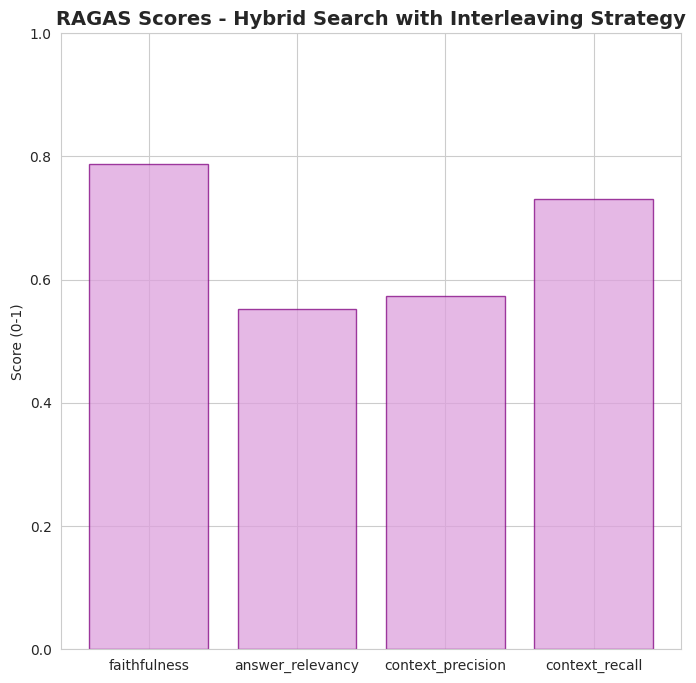

In [ ]:
results_df = ragas_results.to_pandas()
pdf_filename = "RAGAS_Evaluation_Hybrid_Interleaving.pdf"

with PdfPages(pdf_filename) as pdf:
    sns.set_style("whitegrid")
    fig1 = plt.figure(figsize=(8, 8))

    metric_cols = [col for col in ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
                   if col in results_df.columns]

    if metric_cols:
        scores = {col: results_df[col].mean() for col in metric_cols}
        plt.bar(scores.keys(), scores.values(), color='plum', edgecolor='purple', alpha=0.75)
        plt.title("RAGAS Scores - Hybrid Search with Interleaving Strategy", fontsize=14, fontweight='bold')
        plt.ylabel("Score (0-1)")
        plt.ylim(0, 1)

    if metric_cols:
        stats_df = results_df[metric_cols].describe().round(3)
        fig2 = plt.figure(figsize=(10, 6))
        plt.axis('off')
        plt.title("Detailed Statistics", fontsize=16, fontweight='bold', pad=20)

        table = plt.table(cellText=stats_df.values,
                          colLabels=stats_df.columns,
                          rowLabels=stats_df.index,
                          loc='center',
                          cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.2)

        pdf.savefig(fig2)
        plt.close(fig2)

print(f"PDF saved: {pdf_filename}")

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import pandas as pd

# 1. Chuyển đổi kết quả Ragas sang DataFrame
# (Giả sử bạn đã có biến 'ragas_results')
results_df = ragas_results.to_pandas()

# Đặt tên cho 2 file riêng biệt
chart_filename = "RAGAS_Evaluation_Hybrid_Interleaving_Chart.pdf"
table_filename = "RAGAS_Evaluation_Hybrid_Interleaving_Table.pdf"

# ==========================================================
# PHẦN 1: IN CHART (FILE RIÊNG)
# ==========================================================
with PdfPages(chart_filename) as pdf:
    sns.set_style("whitegrid")
    fig1 = plt.figure(figsize=(8, 8))

    metric_cols = [col for col in ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
                   if col in results_df.columns]

    if metric_cols:
        scores = {col: results_df[col].mean() for col in metric_cols}

        # Vẽ biểu đồ (Giữ nguyên màu plum/purple như code gốc)
        plt.bar(scores.keys(), scores.values(), color='plum', edgecolor='purple', alpha=0.75)

        plt.title("RAGAS Scores - Hybrid Search with Interleaving Strategy", fontsize=14, fontweight='bold')
        plt.ylabel("Score (0-1)")
        plt.ylim(0, 1)

        # Thêm hiển thị số liệu trên cột (Optional)
        for i, v in enumerate(scores.values()):
            plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')

        # Lưu biểu đồ
        pdf.savefig(fig1)

    plt.close(fig1)

print(f"✅ Đã lưu Chart vào file: {chart_filename}")

# ==========================================================
# PHẦN 2: IN TABLE (FILE RIÊNG)
# ==========================================================
with PdfPages(table_filename) as pdf:
    metric_cols = [col for col in ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
                   if col in results_df.columns]

    if metric_cols:
        stats_df = results_df[metric_cols].describe().round(3)
        fig2 = plt.figure(figsize=(10, 6))

        plt.axis('off')
        plt.title("Detailed Statistics", fontsize=16, fontweight='bold', pad=20)

        table = plt.table(cellText=stats_df.values,
                          colLabels=stats_df.columns,
                          rowLabels=stats_df.index,
                          loc='center',
                          cellLoc='center')

        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.2)

        # Lưu bảng
        pdf.savefig(fig2)
        plt.close(fig2)

print(f"✅ Đã lưu Table vào file: {table_filename}")

✅ Đã lưu Chart vào file: RAGAS_Evaluation_Hybrid_Interleaving_Chart.pdf
✅ Đã lưu Table vào file: RAGAS_Evaluation_Hybrid_Interleaving_Table.pdf
